In [10]:
# --- imports + setup ---
# run this script every time!

import torch
import numpy as np

from controller import LSTMController
from utils import plot_activations, plot_activations_multi
from matplotlib import pyplot as plt

import sys
sys.path.append('..')

from QMC_mouseUSV.subglottal_pressure import subglottal_pressure
from QMC_mouseUSV.glottal_area import glottal_area
from QMC_mouseUSV.impingement_length import impingement_length
from QMC_mouseUSV.jet_speed import jet_speed_from_pressure
from QMC_mouseUSV.USVfreq import USVfreq

# in model.ipynb, add this to your setup/imports cell
import pickle

with open("../data_prep/pkl-files/pca_model.pkl", "rb") as f:
    pca_full = pickle.load(f)

print("loaded pca model, n_components available:", pca_full.n_components_)
print("imports completed!")

loaded pca model, n_components available: 100
imports completed!


In [2]:
model = LSTMController(pca_dim=10)
# --- fake input: 1 syllable, batch size 1 ---
pca_vector = torch.randn(1, 10)  # random placeholder PCA vector

# --- forward pass through the LSTM ---
activations = model(pca_vector)
print("lstm output shape: " + str(activations.shape))

# unpacking the 4 channels in the order defined in controller.py
# (resp, PCAIA, CT, TA)
resp_activity = activations[..., 0]
PCAIA_activity = activations[..., 1]
CT_activity = activations[..., 2]
TA_activity = activations[..., 3]

# --- run thru the ported hakansson et al. model ---
pressure = subglottal_pressure(resp_activity)
g_area = glottal_area(PCAIA_activity, TA_activity)
imp_length = impingement_length(CT_activity, TA_activity)
speed = jet_speed_from_pressure(g_area, pressure)
predicted_f0 = USVfreq(speed, imp_length)

print("predicted f0 shape: " + str(predicted_f0.shape))
print("predicted f0 sample values: " + str(predicted_f0[0, :5]))

# --- fake ground turth (this is completely random lol) ---
fake_target_f0 = torch.rand_like(predicted_f0) * 50000 + 20000 # arbritrary but still plausible i think?

# --- loss & backward ---
# **REMINDER TO TRY OTHER LOSSES HERE (mse is like my default im sure there are other better ones)
loss = torch.nn.functional.mse_loss(predicted_f0, fake_target_f0)
print("loss: " + str(loss.item()))

loss.backward()

# --- check gradients actually reached the lstm's weights ---
for name, param in model.named_parameters():
    if param.grad is None:
        print("no gradient for " + name)
    else:
        print(f"{name}: grad norm = {param.grad.norm().item():.6f}")


lstm output shape: torch.Size([1, 100, 4])
predicted f0 shape: torch.Size([1, 100])
predicted f0 sample values: tensor([62801.2852, 63114.1523, 63373.9180, 63561.9453, 63687.1328],
       grad_fn=<SliceBackward0>)
loss: 580828288.0
embedding.weight: grad norm = 190433456.000000
embedding.bias: grad norm = 115341688.000000
lstm.weight_ih_l0: grad norm = 745072576.000000
lstm.weight_hh_l0: grad norm = 239949840.000000
lstm.bias_ih_l0: grad norm = 440563008.000000
lstm.bias_hh_l0: grad norm = 440563008.000000
fc.weight: grad norm = 822875712.000000
fc.bias: grad norm = 1502368128.000000


epoch 0: loss = 602726784.00
epoch 20: loss = 75564368.00
epoch 40: loss = 66580204.00
epoch 60: loss = 79015304.00
epoch 80: loss = 70900704.00
epoch 100: loss = 64606224.00
epoch 120: loss = 20266700.00
epoch 140: loss = 5775558.00
epoch 160: loss = 361368.25
epoch 180: loss = 166237.95
epoch 200: loss = 53858.29
epoch 220: loss = 34846.48
epoch 240: loss = 25861.44
epoch 260: loss = 19762.52
epoch 280: loss = 15442.75
final loss: 12474.10


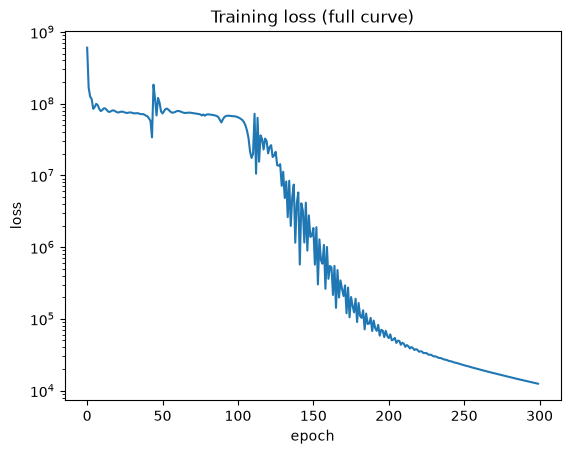

predicted f0 range: 29766.560546875 59738.90625
target f0 range: 30000.0 60000.0
beta range: 0.5484784841537476 0.5839261412620544


In [5]:
model = LSTMController(pca_dim=10)

# --- training loop with completely synethetic target f0 ---

# REMEMBER TO CHANGE LR its too high rn (set maybe to like 1e-3?)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

pca_vector = torch.randn(1,10)
fake_target_f0 = torch.linspace(30000, 60000, 100).unsqueeze(0)  # smooth curve, 30kHz -> 60kHz over the syllable

losses = []

for epoch in range(300):
    optimizer.zero_grad()

    activations = model(pca_vector)
    resp_activity = activations[..., 0]
    PCAIA_activity = activations[..., 1]
    CT_activity = activations[..., 2]
    TA_activity = activations[..., 3]

    pressure = subglottal_pressure(resp_activity)
    g_area = glottal_area(PCAIA_activity, TA_activity)
    imp_length = impingement_length(CT_activity, TA_activity)
    speed = jet_speed_from_pressure(g_area, pressure)
    predicted_f0 = USVfreq(speed, imp_length)

    loss = torch.nn.functional.mse_loss(predicted_f0, fake_target_f0)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 20 == 0:
        print(f"epoch {epoch}: loss = {loss.item():.2f}")

print(f"final loss: {losses[-1]:.2f}")

# graph loss over time
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.yscale("log")  # helpful when values span multiple orders of magnitude
plt.title("Training loss (full curve)")
plt.show()

# check the mucsle activations after training
with torch.no_grad():
    activations_start_check = model(pca_vector)
    pred_check = USVfreq(
        jet_speed_from_pressure(
            glottal_area(activations_start_check[...,1], activations_start_check[...,3]),
            subglottal_pressure(activations_start_check[...,0])
        ),
        impingement_length(activations_start_check[...,2], activations_start_check[...,3])
    )
    print("predicted f0 range:", pred_check.min().item(), pred_check.max().item())
    print("target f0 range:", fake_target_f0.min().item(), fake_target_f0.max().item())

    g_area_check = glottal_area(activations_start_check[...,1], activations_start_check[...,3])
    tracheal_diameter = 2 * torch.sqrt(torch.tensor(0.95e-6) / torch.pi)
    glottal_diameter = 2 * torch.sqrt(g_area_check / torch.pi)
    beta_check = glottal_diameter / tracheal_diameter
    print("beta range:", beta_check.min().item(), beta_check.max().item())

In [9]:
# get one real pca vector working

with open("../data_prep/pkl-files/sample_trajectories.pkl", "rb") as f:
    sample_trajectories = pickle.load(f)

print(f"Loaded {len(sample_trajectories)} sample trajectories, shape of first:", sample_trajectories[0].shape)

Loaded 10 sample trajectories, shape of first: (100,)


In [11]:
# --- pick one real trajectory ---
real_trajectory = sample_trajectories[0]  # shape (100,)

# --- center it the same way PCA was fit (subtract its own mean) ---
real_trajectory_centered = real_trajectory - real_trajectory.mean()

# --- project into PCA space, keep only the first 10 components ---
real_pca_vector = pca_full.transform(real_trajectory_centered.reshape(1, -1))[:, :10]
pca_vector = torch.tensor(real_pca_vector, dtype=torch.float32)
print("pca_vector shape:", pca_vector.shape)

# --- real target: the ACTUAL trajectory, uncentered ---
real_target_f0 = torch.tensor(real_trajectory, dtype=torch.float32).unsqueeze(0)
print("real_target_f0 shape:", real_target_f0.shape)

pca_vector shape: torch.Size([1, 10])
real_target_f0 shape: torch.Size([1, 100])
